## Step: Handling fully-empty columns
Dropped 14 columns that were 100% missing (e.g., host_about, license) —
these fields simply weren't captured in Bangkok's scrape. Not a data
quality issue, just missing by design in this dataset.

In [127]:
import pandas as pd


In [128]:
listings = pd.read_csv('/content/listings.csv.gz')
reviews = pd.read_csv('/content/reviews.csv')
neighbourhoods= pd.read_csv('/content/neighbourhoods.csv')


In [129]:
df = listings.copy()

In [130]:
df.shape

(31069, 90)

In [131]:
df.head(1)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,262923052,...,4.95,4.73,4.55,NaN,NaN,44,44,0,0,0.68


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31069 entries, 0 to 31068
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            31069 non-null  int64  
 1   listing_url                                   31069 non-null  object 
 2   scrape_id                                     31069 non-null  int64  
 3   last_scraped                                  31069 non-null  object 
 4   source                                        31069 non-null  object 
 5   name                                          31069 non-null  object 
 6   description                                   30490 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   31069 non-null  object 
 9   host_id                                       31069 non-null 

In [133]:
df.index

RangeIndex(start=0, stop=31069, step=1)

In [134]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.106900e+04,3.106900e+04,0.0,3.106900e+04,3.106900e+04,0.0,31069.000000,31069.000000,31069.000000,31069.000000,...,20815.000000,20814.000000,20813.000000,0.0,0.0,31069.000000,31069.000000,31069.000000,31069.000000,20816.000000
mean,1.019842e+18,2.026063e+13,NaN,1.899194e+16,1.478389e+18,NaN,6.056970,5.368502,4.650713,5.335028,...,4.784868,4.668731,4.649647,NaN,NaN,32.449870,25.349866,6.643310,0.311275,1.005685
std,6.027655e+17,4.875078e+00,NaN,1.779345e+17,4.135058e+16,NaN,4.047831,3.414538,3.753182,3.368784,...,0.509846,0.473936,0.545395,NaN,NaN,49.412978,44.926178,23.407401,3.118309,2.028137
min,2.793400e+04,2.026063e+13,NaN,1.498300e+04,1.462507e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,7.198804e+17,2.026063e+13,NaN,6.934601e+07,1.463342e+18,NaN,2.000000,2.000000,1.000000,2.000000,...,4.800000,4.570000,4.590000,NaN,NaN,3.000000,1.000000,0.000000,0.000000,0.190000
50%,1.228113e+18,2.026063e+13,NaN,2.648650e+08,1.468251e+18,NaN,7.000000,5.000000,3.000000,5.000000,...,4.950000,4.790000,4.800000,NaN,NaN,10.000000,4.000000,0.000000,0.000000,0.510000
75%,1.521708e+18,2.026063e+13,NaN,5.486454e+08,1.470360e+18,NaN,10.000000,8.000000,8.000000,8.000000,...,5.000000,5.000000,5.000000,NaN,NaN,41.000000,29.000000,4.000000,0.000000,1.270000
max,1.717918e+18,2.026063e+13,NaN,1.718980e+18,1.718985e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,NaN,NaN,247.000000,238.000000,231.000000,62.000000,150.180000


In [135]:
 null = df.isnull().sum()
 null_columns  = null[null == df.shape[0]].index
 null_columns




Index(['neighborhood_overview', 'host_since', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url',
       'host_neighbourhood', 'host_total_listings_count', 'host_verifications',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated',
       'license', 'instant_bookable'],
      dtype='object')

In [136]:
df = df.drop(columns = null_columns)

In [137]:
df.shape

(31069, 76)

## Step: Near-complete columns (nights group + host_profile_url)

7 columns had only 2 missing rows (7948, 28024) — verified these are real,
active listings, not broken data. Found strong right-skew in the numeric
columns (e.g., max_nights: median=365, mean=553,596), so imputed using median
instead of mean. host_profile_url left as NaN — not relevant to pricing analysis.

In [138]:
 null_summary =  df.isnull().sum()
 null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
review_scores_accuracy,10253
last_review,10253
first_review,10253
review_scores_cleanliness,10253
review_scores_rating,10253


In [139]:
df[df['maximum_minimum_nights'].isnull()]['maximum_minimum_nights']


,maximum_minimum_nights
7948,NaN
28024,NaN


In [140]:
df.loc[[7948	, 28024]]


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
7948,1617296148612092610,https://www.airbnb.com/rooms/1617296148612092610,20260629030312,2026-07-02,city scrape,Lumpiniville Sukhumvit,Long-term stay booking promotions are availabl...,https://a0.muscache.com/pictures/hosting/Hosti...,443225687,https://www.airbnb.com/users/show/443225687,...,4.56,4.56,4.78,4.67,4.78,1,0,1,0,1.91
28024,1168646596769294566,https://www.airbnb.com/rooms/1168646596769294566,20260629030312,2026-07-02,city scrape,c Super Luxury Villa-like Condo 10mins Ekkamai,A super luxurious and stylish villa-like condo...,https://a0.muscache.com/pictures/9f630b53-6e09...,234983307,https://www.airbnb.com/users/show/234983307,...,5.00,5.00,5.00,4.85,4.77,19,19,0,0,0.58


In [141]:
df.loc[[7948	, 28024]].isnull().sum().sort_values(ascending = False).head(10)


,0
maximum_minimum_nights,2
minimum_minimum_nights,2
maximum_nights,2
minimum_nights,2
maximum_maximum_nights,2
minimum_maximum_nights,2
host_about,1
host_location,1
id,0
listing_url,0


In [142]:
# df['maximum_minimum_nights'].median()
# df['minimum_minimum_nights'].median()
# df['minimum_maximum_nights'].median()
# df['maximum_maximum_nights'].median()




In [143]:
df['maximum_minimum_nights'].median()
df['minimum_minimum_nights'].median()
df['maximum_maximum_nights'].median()
df['minimum_maximum_nights'].median()
df['maximum_nights'].median()
df['minimum_nights'].median()



2.0

In [144]:
df['maximum_minimum_nights'].mean()
df['minimum_minimum_nights'].mean()
df['maximum_maximum_nights'].mean()
df['minimum_maximum_nights'].mean()
df['maximum_nights'].mean()
df['minimum_nights'].mean()


np.float64(12.783274857565907)

In [145]:
cols_to_fill = ['maximum_minimum_nights' , 'minimum_minimum_nights' , 'maximum_maximum_nights' , 'minimum_maximum_nights' , 'maximum_nights' , 'minimum_nights' ]


In [146]:
for col in cols_to_fill :
  df[col] = df[col].fillna(df[col].median())


In [147]:
df[cols_to_fill].isnull().sum()

,0
maximum_minimum_nights,0
minimum_minimum_nights,0
maximum_maximum_nights,0
minimum_maximum_nights,0
maximum_nights,0
minimum_nights,0


In [148]:
 null_summary =  df.isnull().sum()
 null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
first_review,10253
review_scores_cleanliness,10253
review_scores_accuracy,10253
last_review,10253
review_scores_rating,10253


In [149]:
df[df['host_profile_url'].isnull()].isnull().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
...,...
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0
calculated_host_listings_count_shared_rooms,0


In [150]:
df['host_profile_url']

,host_profile_url
0,https://www.airbnb.com/users/profile/146939044...
1,https://www.airbnb.com/users/profile/146920674...
2,https://www.airbnb.com/users/profile/146959592...
3,https://www.airbnb.com/users/profile/146530973...
4,https://www.airbnb.com/users/profile/147072381...
...,...
31064,https://www.airbnb.com/users/profile/152953686...
31065,https://www.airbnb.com/users/profile/151083228...
31066,https://www.airbnb.com/users/profile/147040601...
31067,https://www.airbnb.com/users/profile/151083228...


## Step: bathrooms, bedrooms, beds

Checked median by room_type before deciding fill strategy. Found medians
were nearly identical across room types in this dataset, but chose to
impute using room_type-grouped median anyway (rather than flat overall
median) since it's conceptually more accurate and costs nothing extra.
Used median over mean due to right-skew from outliers (e.g., 50 bathrooms).

In [151]:
df.head(1)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.45,4.86,4.95,4.73,4.55,44,44,0,0,0.68


In [152]:
 null_summary =  df.isnull().sum()
 null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
first_review,10253
review_scores_cleanliness,10253
review_scores_accuracy,10253
last_review,10253
review_scores_rating,10253


In [153]:
[col for col in df.columns if 'review' in col.lower()]

['number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'number_of_reviews_ly',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'reviews_per_month']

In [154]:
df[df['number_of_reviews'] == 0].shape

(10253, 76)

In [155]:
df['has_reviews'] = df['number_of_reviews'] > 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


In [156]:
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [157]:
df.head(1)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.86,4.95,4.73,4.55,44,44,0,0,0.68,True


In [158]:
 null_summary =  df.isnull().sum()
 null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
review_scores_cleanliness,10253
review_scores_accuracy,10253
review_scores_rating,10253
first_review,10253
last_review,10253


In [159]:
df[['bathrooms', 'bedrooms', 'beds']].describe()

,bathrooms,bedrooms,beds
count,26947.000000,27172.000000,28418.000000
mean,1.381156,1.455101,1.830952
std,1.117763,1.287158,2.027435
min,0.500000,0.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,2.000000,2.000000
max,50.000000,50.000000,60.000000


In [160]:
df['room_type'].head()

,room_type
0,Entire home/apt
1,Private room
2,Entire home/apt
3,Private room
4,Entire home/apt


In [161]:
df.groupby('room_type')[['bathrooms' , 'bedrooms' , 'beds']].median()

,bathrooms,bedrooms,beds
room_type,,,
Entire home/apt,1.0,1.0,1.0
Hotel room,1.0,1.0,1.0
Private room,1.0,1.0,1.0
Shared room,1.0,1.0,2.0


In [162]:
for col in ['bathrooms', 'bedrooms', 'beds']:
    df[col] = df.groupby('room_type')[col].transform(lambda x: x.fillna(x.median()))

print(df[['bathrooms', 'bedrooms', 'beds']].isnull().sum())


bathrooms    0
bedrooms     0
beds         0
dtype: int64


In [163]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
first_review,10253
last_review,10253
review_scores_rating,10253
review_scores_accuracy,10253
review_scores_cleanliness,10253


In [164]:
df['bathrooms_text']

,bathrooms_text
0,Half-bath
1,8 shared baths
2,1.5 baths
3,1 bath
4,1.5 baths
...,...
31064,1 bath
31065,1 bath
31066,1 private bath
31067,1 bath


## Step: price (target variable) - dropped missing rows

2082 rows missing price. Checked has_availability, reviews, availability_365 —
no clear "inactive listing" pattern found. Price-derived columns
(price_quote_*, estimated_revenue) missing the same rows — likely a scraping
gap, not bad data. Dropped these rows rather than impute, since price is the
target variable and shouldn't be faked.

In [165]:
df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.86,4.95,4.73,4.55,44,44,0,0,0.68,True
1,30779635,https://www.airbnb.com/rooms/30779635,20260629030312,2026-07-02,previous scrape,Private Dormitory for 12 person,10 Bed Mixed Dormitory. Rest easy in our spaci...,https://a0.muscache.com/pictures/3ef98ba3-22d7...,226784821,https://www.airbnb.com/users/show/226784821,...,NaN,NaN,NaN,NaN,8,0,6,2,0.00,False


In [166]:
null_summary = df.isnull().sum()
null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11988
review_scores_value,10256
review_scores_checkin,10255
review_scores_location,10255
review_scores_communication,10254
first_review,10253
last_review,10253
review_scores_rating,10253
review_scores_accuracy,10253
review_scores_cleanliness,10253


In [167]:
df[['bathrooms' , 'bedrooms' , 'beds']].isnull().sum()

,0
bathrooms,0
bedrooms,0
beds,0


In [168]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id',
       'host_profile_url', 'host_name', 'hosts_time_as_user_years',
       'hosts_time_as_user_months', 'hosts_time_as_host_years',
       'hosts_time_as_host_months', 'host_location', 'host_about',
       'host_is_superhost', 'host_picture_url', 'host_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_total_price',
       'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg

In [169]:
df[df['price'].isnull()][['room_type', 'has_availability', 'number_of_reviews', 'availability_365']].describe(include='all')

,room_type,has_availability,number_of_reviews,availability_365
count,2082,1872,2082.00000,2082.000000
unique,4,1,NaN,NaN
top,Entire home/apt,t,NaN,NaN
freq,1500,1872,NaN,NaN
mean,NaN,NaN,13.68828,125.119597
std,NaN,NaN,37.92992,153.436586
min,NaN,NaN,0.00000,0.000000
25%,NaN,NaN,0.00000,0.000000
50%,NaN,NaN,2.00000,0.500000
75%,NaN,NaN,12.00000,300.000000


In [170]:
df.shape

(31069, 77)

In [171]:
df = df.dropna(subset = ['price'])
df.shape

(28987, 77)

In [172]:
null_summary = df.isnull().sum()
null_summary[null_summary > 0].sort_values(ascending = False)


,0
host_about,11177
review_scores_value,9454
review_scores_checkin,9453
review_scores_location,9453
review_scores_communication,9452
first_review,9451
review_scores_cleanliness,9451
review_scores_accuracy,9451
review_scores_rating,9451
last_review,9451


## Step: Final missing-value decisions

host_about: engineered has_about boolean flag (missing bio may weakly signal
host trust/quality, worth testing against price later).

host_location, description, bathrooms_text: low relevance to pricing question,
left as NaN — no flag created, avoids adding noise features without a clear reason.

has_availability: only 9 rows missing, dropped them.

Review-score columns remain NaN (already explained earlier — no reviews yet,
not a data error). Missing-value cleaning phase now complete.

In [173]:
null_summary = df.isnull().sum()
null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11177
review_scores_value,9454
review_scores_checkin,9453
review_scores_location,9453
review_scores_communication,9452
first_review,9451
review_scores_cleanliness,9451
review_scores_accuracy,9451
review_scores_rating,9451
last_review,9451


In [174]:
df = df.dropna(subset = ['has_availability'])

In [175]:
df['has_about'] = df['host_about'].notna()

In [176]:
df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews,has_about
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.95,4.73,4.55,44,44,0,0,0.68,True,True
2,1137290659996617307,https://www.airbnb.com/rooms/1137290659996617307,20260629030312,2026-06-29,city scrape,Panda家庭房/儿童床/婴儿床/可加沙发床/中泰房东,You'll have a great time at this comfortable p...,https://a0.muscache.com/pictures/hosting/Hosti...,315766536,https://www.airbnb.com/users/show/315766536,...,3.00,4.00,3.00,48,46,1,1,0.04,True,True


In [177]:
null_summary = df.isnull().sum()
null_summary[null_summary > 0].sort_values(ascending = False)

,0
host_about,11177
review_scores_value,9447
review_scores_checkin,9446
review_scores_location,9446
review_scores_communication,9445
review_scores_cleanliness,9444
review_scores_accuracy,9444
review_scores_rating,9444
first_review,9444
last_review,9444


## Baseline: Median price by neighbourhood + room_type

Calculated median price grouped by neighbourhood_cleansed + room_type as a
naive baseline (157 groups). Median across groups ≈ ฿1,259, but huge spread:
min ฿299, max ฿11,412 (38x range). Shows location + room type alone explain
massive price variation in Bangkok's market. This becomes the benchmark any
future prediction model would need to beat.

In [178]:
df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews,has_about
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.95,4.73,4.55,44,44,0,0,0.68,True,True
2,1137290659996617307,https://www.airbnb.com/rooms/1137290659996617307,20260629030312,2026-06-29,city scrape,Panda家庭房/儿童床/婴儿床/可加沙发床/中泰房东,You'll have a great time at this comfortable p...,https://a0.muscache.com/pictures/hosting/Hosti...,315766536,https://www.airbnb.com/users/show/315766536,...,3.00,4.00,3.00,48,46,1,1,0.04,True,True


In [179]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3260/2337335738.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


In [180]:
baseline = df.groupby(['neighbourhood_cleansed' , 'room_type'])['price'].median()

In [181]:
baseline

neighbourhood_cleansed  room_type      
Bang Bon                Entire home/apt    2526.500
                        Private room        904.400
Bang Kapi               Entire home/apt    1141.200
                        Private room       1085.000
                        Shared room         407.500
                                             ...   
Wang Thong Lang         Shared room         301.270
Yan na wa               Entire home/apt    1258.670
                        Hotel room         1000.000
                        Private room        964.295
                        Shared room         414.410
Name: price, Length: 157, dtype: float64

In [182]:
baseline.describe()

,price
count,157.000000
mean,1528.632675
std,1343.218563
min,298.530000
25%,860.000000
50%,1258.670000
75%,1815.000000
max,11412.000000


## Hypothesis 1: Bedrooms/bathrooms directly drive price — REJECTED

Correlation with price: bedrooms=0.08, bathrooms=0.08, beds=0.07 — very weak.
Size alone doesn't explain price variation much. Possible reasons: outliers
skewing the relationship, room_type may matter more than raw size, or
relationship isn't linear. Worth testing room_type next.

In [183]:
df[['price' , 'bedrooms' , 'bathrooms' , 'beds']].corr()['price']

,price
price,1.000000
bedrooms,0.081574
bathrooms,0.082180
beds,0.068031


## Hypothesis 2: Room type vs neighbourhood — room type wins

Compared spread of median prices: room_type std = 674, neighbourhood std = 414.
Room type creates ~63% more price variation than neighbourhood. Makes sense —
room type (shared vs private vs entire home) is a bigger structural difference
than location alone. Room type appears to be the stronger price driver so far.

In [184]:
df.groupby('room_type')['price'].median().sort_values(ascending = False)

,price
room_type,
Hotel room,1972.00
Entire home/apt,1715.00
Private room,1389.74
Shared room,431.22


In [185]:
df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending = False)

,price
neighbourhood_cleansed,
Parthum Wan,2652.550
Vadhana,2220.440
Lat Phrao,2182.000
Samphanthawong,2181.995
Bang Rak,2043.000
Bueng Kum,2031.810
Khlong Toei,1820.560
Pom Prap Sattru Phai,1754.985
Ratchathewi,1750.000


In [186]:
room_type_std = df.groupby('room_type')['price'].median().std()
neighbourhood_std = df.groupby('neighbourhood_cleansed')['price'].median().std()

In [187]:
room_type_std

674.0254979351054

In [188]:
neighbourhood_std

413.49663420327715

## Hypothesis 3: Reviews affect price — REJECTED

Median price: no reviews = ฿1601, has reviews = ฿1580. Nearly identical,
negligible difference. Having reviews (or not) doesn't meaningfully relate
to price. Hosts don't appear to price new/unreviewed listings differently.

In [189]:
df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews,has_about
0,979584324955463360,https://www.airbnb.com/rooms/979584324955463360,20260629030312,2026-07-02,city scrape,厨房可做饭免费Wi-Fi健身房泳池800米到坚果地铁站旅游打卡地,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,262923052,https://www.airbnb.com/users/show/262923052,...,4.95,4.73,4.55,44,44,0,0,0.68,True,True
2,1137290659996617307,https://www.airbnb.com/rooms/1137290659996617307,20260629030312,2026-06-29,city scrape,Panda家庭房/儿童床/婴儿床/可加沙发床/中泰房东,You'll have a great time at this comfortable p...,https://a0.muscache.com/pictures/hosting/Hosti...,315766536,https://www.airbnb.com/users/show/315766536,...,3.00,4.00,3.00,48,46,1,1,0.04,True,True


In [190]:
df.groupby('has_reviews')['price'].median()



,price
has_reviews,
False,1600.90
True,1579.53


In [191]:
df['has_reviews'].value_counts()


,count
has_reviews,
True,19534
False,9444


## Outlier discovery: extreme price listings

Found 7 listings priced above ฿900,000/night — implausible for any Bangkok
property. 3 had names explicitly indicating "not for sale/room swap"
(Chinese text). Other 4 had normal-looking names but equally implausible
prices — likely data entry errors or the same unbookable-pricing pattern
without a naming clue. Removed all 7 (price < 500000) as non-market prices.

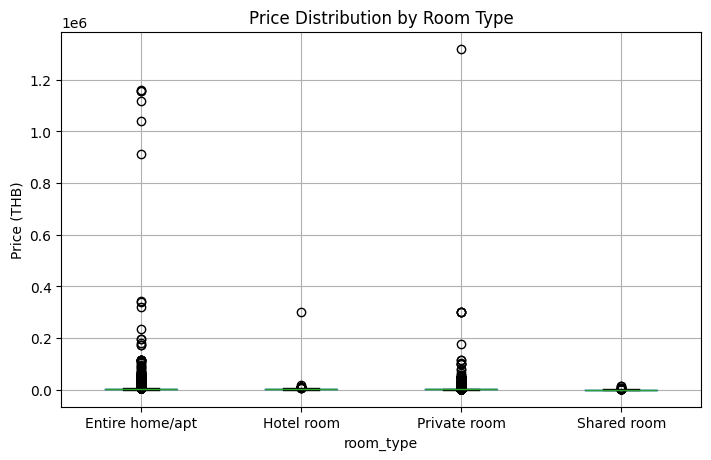

In [192]:
import matplotlib.pyplot as plt
df.boxplot(column = 'price' , by = 'room_type' , figsize = (8,5))
plt.title('Price Distribution by Room Type')
plt.suptitle('')
plt.ylabel('Price (THB)')
plt.show()

In [193]:
df[df['price'] > 500000][['name' , 'room_type' , 'neighbourhood_cleansed' , 'price' , 'availability_365']]

,name,room_type,neighbourhood_cleansed,price,availability_365
1353,调房备用-fkbk010,Entire home/apt,Khlong Toei,1118917.14,365
2151,"Modern&Luxury apartment,5min to MRT,freeWifi",Entire home/apt,Huai Khwang,1157401.00,365
4647,Ideo verse ratchaprarop condo,Private room,Ratchathewi,1320255.00,365
23472,bkce调房（不售卖）,Entire home/apt,Vadhana,1039152.50,269
26485,"Resort Style Luxury apartment,5min to MRT,free...",Entire home/apt,Huai Khwang,1159508.00,365
28250,调房链接（不售卖）,Entire home/apt,Vadhana,912940.69,365
30854,Bangkok City 100m to Ploenchit SkyTrain w/ Tub,Entire home/apt,Parthum Wan,1157979.00,266


In [194]:
df = df[df['price'] < 500000]

In [195]:
df.shape

(28971, 78)

## Room type - refined finding

Log-scale boxplot reveals: Entire home/apt, Hotel room, and Private room have
similar median prices (฿1500-2000) with heavy overlap. Shared room is the
clear outlier — notably cheaper (฿400-500 median). The earlier "room_type
std" finding was mostly driven by Shared room being different, not a smooth
gradient across all 4 types. All categories (except Shared room) have long
tails of legitimate high-end listings (villas, premium condos) — kept in the
dataset as real market data, not errors.

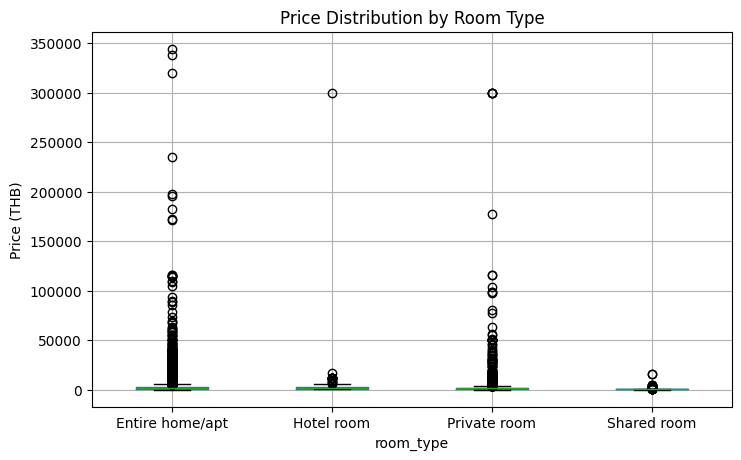

In [196]:
df.boxplot(column = 'price' , by = 'room_type' , figsize = (8,5))
plt.title('Price Distribution by Room Type')
plt.suptitle('')
plt.ylabel('Price (THB)')
plt.show()

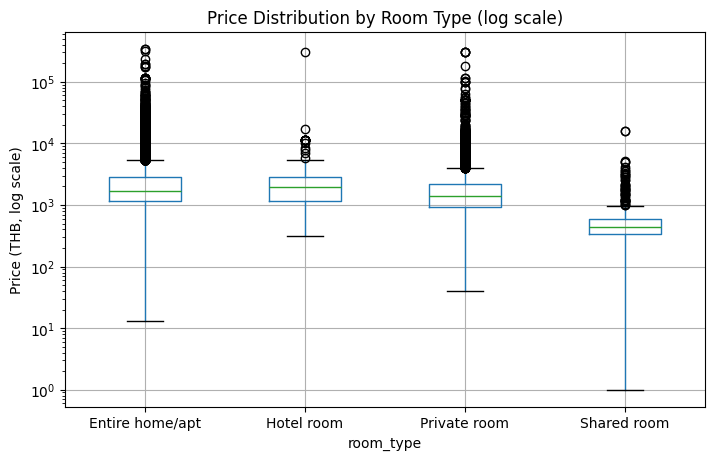

In [197]:
import matplotlib.pyplot as plt
df.boxplot(column='price', by='room_type', figsize=(8,5))
plt.yscale('log')
plt.title('Price Distribution by Room Type (log scale)')
plt.suptitle('')
plt.ylabel('Price (THB, log scale)')
plt.show()

## Neighbourhood - refined finding

Top 10 neighbourhoods by median price show heavy overlap in full price
distribution (log-scale boxplot) — medians cluster ฿1500-3000 across nearly
all of them, no clean separation even among the "priciest" areas. This
contrasts with room_type, where Shared room was a clearly distinct, separate
group. Combined with earlier std comparison, this suggests location alone
(among the priciest areas) doesn't cleanly separate price tiers — there's
likely huge listing-to-listing variation within any single neighbourhood,
probably driven more by property type/quality than area.

In [198]:
#gbvcsd

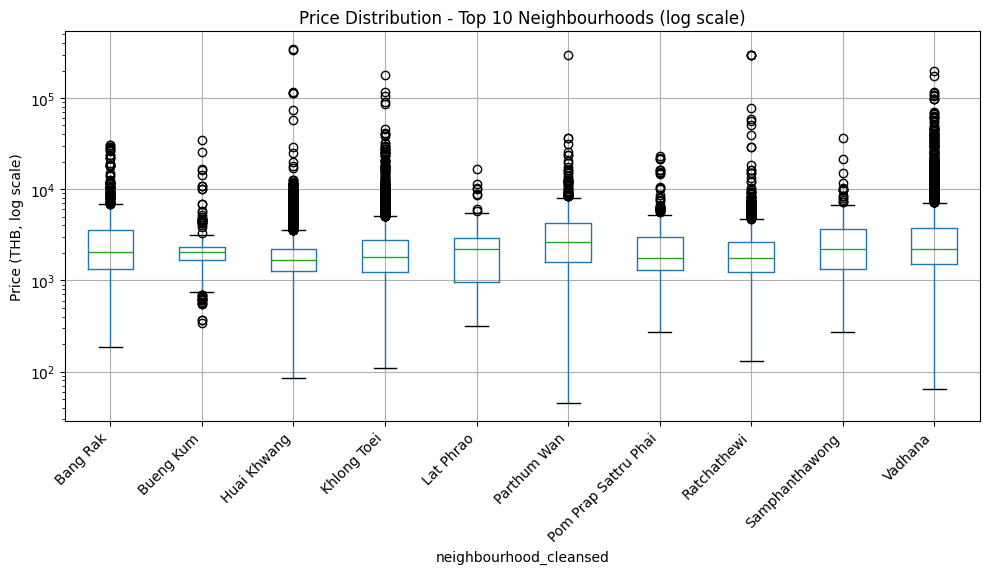

In [199]:
top10_neighbourhoods = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).head(10).index

subset = df[df['neighbourhood_cleansed'].isin(top10_neighbourhoods)]

import matplotlib.pyplot as plt

subset.boxplot(column='price', by='neighbourhood_cleansed', figsize=(10,6))
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution - Top 10 Neighbourhoods (log scale)')
plt.suptitle('')
plt.ylabel('Price (THB, log scale)')
plt.tight_layout()
plt.show()


## Hypothesis 4: Superhost status affects price — SUPPORTED (modestly)

Median price: Superhost = ฿1686, Non-superhost = ฿1532 (~10% higher for
Superhosts). Modest but real difference — makes sense given Superhosts are
typically more experienced/trusted, may command a slight premium.

In [200]:
x =[col for col in df.columns if 'host' in  col.lower()]

In [201]:
df['host_is_superhost'].value_counts()

,count
host_is_superhost,
f,18668
t,10303


## Hypothesis 5: Multi-listing (professional) hosts price differently — REJECTED

Median price nearly identical: single-listing hosts ฿1636, multi-listing
hosts ฿1585. Being a "professional"/portfolio host doesn't meaningfully
relate to pricing.

In [202]:
df['is_multi_listing_host'] = df['calculated_host_listings_count'] > 1

In [203]:
df.groupby('is_multi_listing_host')['price'].median()

,price
is_multi_listing_host,
False,1636.11
True,1585.07


In [204]:
df['is_multi_listing_host'].value_counts()

,count
is_multi_listing_host,
True,25071
False,3900


## Checked neighbourhoods.csv

Simple 50-row reference list of neighbourhood names. neighbourhood_group is
fully empty — Bangkok has no borough-style grouping (unlike cities like NYC).
No additional useful info beyond names already present in listings.csv
(neighbourhood_cleansed). Not used further in this analysis; would only
be useful for geographic mapping if paired with neighbourhoods.geojson.

In [205]:
df = reviews.copy()

In [206]:
df.head()

,listing_id,date
0,27934,2012-04-07
1,27934,2012-05-07
2,27934,2012-06-20
3,27934,2012-07-08
4,27934,2012-08-13


In [207]:
df.tail()

,listing_id,date
693642,1713793978047562735,2026-06-30
693643,1713805239942509562,2026-06-28
693644,1714254698741796121,2026-06-26
693645,1714405064935274536,2026-06-28
693646,1715203487815634408,2026-06-25


In [208]:
df.shape

(693647, 2)

In [209]:
x = df['date']

In [210]:
df['date'] = pd.to_datetime(x)

In [211]:
df['date'].dt.month.value_counts().sort_values(ascending = False)

,count
date,
1,79225
2,70945
12,67674
3,66466
11,59800
4,58994
5,54450
6,50885
8,49127


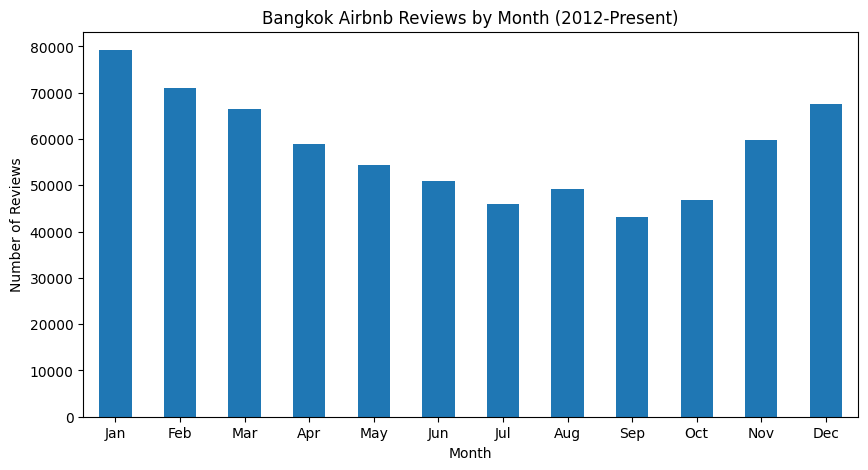

In [212]:

monthly_reviews_ordered = df.groupby(df['date'].dt.month).size().sort_index()
plt.figure(figsize=(10,5))
monthly_reviews_ordered.plot(kind='bar')
plt.title('Bangkok Airbnb Reviews by Month (2012-Present)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.show()

## Time-based analysis: Seasonality confirmed

Review counts by month (2012-present, 693K reviews) show clear seasonality:
peak Nov-Mar (cool/dry season), trough Jun-Sep (rainy season). Jan highest
(79K reviews), Sep lowest (43K) — nearly 2x difference. Matches known Bangkok
tourism patterns, validating that review volume is a reasonable proxy for
guest activity. Useful for hosts: pricing/availability strategy could account
for this predictable demand cycle.

In [213]:
df = neighbourhoods.copy()

In [214]:
df.head()

,neighbourhood_group,neighbourhood
0,NaN,Bang Bon
1,NaN,Bang Kapi
2,NaN,Bang Khae
3,NaN,Bang Khen
4,NaN,Bang Kho laen


In [215]:
df.tail()

,neighbourhood_group,neighbourhood
45,NaN,Thon buri
46,NaN,Thung khru
47,NaN,Vadhana
48,NaN,Wang Thong Lang
49,NaN,Yan na wa


In [216]:
df.shape

(50, 2)

In [217]:
df.isnull().value_counts()

,,count
neighbourhood_group,neighbourhood,
True,False,50


In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        50 non-null     object 
dtypes: float64(1), object(1)
memory usage: 932.0+ bytes


# EDA Summary: What Drives Airbnb Prices in Bangkok?

## Data Cleaning
Started with 90 columns, 31,069 rows. Dropped 14 fully-empty columns.
Investigated near-complete columns (7 cols, 2 rows) — confirmed legitimate
listings with a scraping gap, imputed using median (strong right-skew from
platform-max placeholder values). Handled bathrooms/bedrooms/beds with
room_type-grouped median. Dropped 2,082 rows with missing price (target
variable) after ruling out "inactive listing" explanation — likely a
scraping/API failure. Engineered has_reviews, has_about, and
is_multi_listing_host flags. Removed 7 extreme-outlier listings (>฿900K/night)
— identified as intentionally unbookable "not for sale" listings. Final
dataset: ~29,000 rows, cleaned and analysis-ready.

## Baseline
Median price by neighbourhood + room_type (157 groups): overall median
≈ ฿1,259/night, ranging from ฿299 to ฿11,412 (38x spread).

## Hypotheses Tested
1. **Size (bedrooms/bathrooms/beds) drives price** — REJECTED. Correlation
near zero (0.07–0.08).

2. **Room type vs. neighbourhood** — SUPPORTED (room type). Room type
median-price std (674) exceeds neighbourhood std (414). Shared room is a
clearly distinct, cheaper category (~฿400-500 median); other room types
overlap heavily (~฿1500-2000 median). Neighbourhood shows heavy overlap
even among top-10 priciest areas.

3. **Reviews affect price** — REJECTED. Nearly identical medians (฿1580
vs ฿1601) across large groups (19,534 vs 9,444).

4. **Superhost status affects price** — SUPPORTED (modestly). Superhosts
median ฿1686 vs ฿1532 for non-superhosts (~10% premium), across solid
sample sizes (10,303 vs 18,668).

5. **Multi-listing (professional) hosts price differently** — REJECTED.
Nearly identical medians (฿1585 vs ฿1636).

## Bonus: Seasonality (reviews.csv)
693K reviews (2012–present) show clear seasonality matching Bangkok's
tourism calendar: peak Nov–Mar (cool/dry season), trough Jun–Sep (rainy
season). January highest (79K reviews), September lowest (43K) — nearly
2x difference.

## Key Insight
Room type (Shared vs. non-shared) is the strongest price signal found,
ahead of property size, reviews, and location. Superhost status offers a
modest premium. Multi-listing/professional hosts don't price differently
than individual hosts. Review activity follows a strong, predictable
seasonal pattern tied to Thailand's tourism calendar.

## Status
Core EDA complete. Dataset is clean and structured well enough to serve
as a backup Sem 4 price-prediction project if needed — price is the
natural target, with room_type and superhost status as known predictors.